In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf, tf_keras
import os
import seaborn as sns
from tensorflow.keras import mixed_precision

# Import the MoViNet model from TensorFlow Models (tf-models-official) for the MoViNet model
from official.projects.movinet.modeling import movinet, movinet_model

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# Enable mixed precision
mixed_precision.set_global_policy('mixed_float16')


In [3]:
IMAGE_HEIGHT, IMAGE_WIDTH = 112, 112

SEQUENCE_LENGTH = 10

CLASSES_LIST = ['NonViolence', 'Violence']

BATCH_SIZE = 8

DATA_DIR = "../data/ProcessedDataMoViNet/"

In [4]:
train_ds = tf.data.Dataset.load(os.path.join(DATA_DIR, "train_ds"))
val_ds = tf.data.Dataset.load(os.path.join(DATA_DIR, "val_ds"))

In [5]:
MODEL_ID = 'a0'

tf.keras.backend.clear_session()

backbone = movinet.Movinet(model_id=MODEL_ID, causal=True)

model_cfg = backbone.from_config(backbone.get_config())


In [6]:
model_cfg.num_classes = len(CLASSES_LIST)
model_cfg.input_specs = {'shape': (None, SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3), 'dtype': tf.float32}


In [7]:
model = movinet_model.MovinetClassifier(model_cfg, num_classes=len(CLASSES_LIST))

In [8]:

model.build([None, SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3])

In [9]:
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

In [10]:
callbacks = [
    tf_keras.callbacks.ModelCheckpoint(
        filepath='../models/movinet_a0.h5',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),

    tf_keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf_keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]

In [11]:
results = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
)

Epoch 1/20

225/225 [==============================] - ETA: 0s - loss: 0.6408 - accuracy: 0.6550 
Epoch 1: val_accuracy improved from -inf to 0.74500, saving model to ../models\movinet_a0.h5
225/225 [==============================] - 2634s 12s/step - loss: 0.6408 - accuracy: 0.6550 - val_loss: 0.5559 - val_accuracy: 0.7450 - lr: 0.0010
Epoch 2/20
225/225 [==============================] - ETA: 0s - loss: 0.4841 - accuracy: 0.7722 
Epoch 2: val_accuracy improved from 0.74500 to 0.79500, saving model to ../models\movinet_a0.h5
225/225 [==============================] - 2753s 12s/step - loss: 0.4841 - accuracy: 0.7722 - val_loss: 0.4615 - val_accuracy: 0.7950 - lr: 0.0010
Epoch 3/20
225/225 [==============================] - ETA: 0s - loss: 0.3889 - accuracy: 0.8350 
Epoch 3: val_accuracy improved from 0.79500 to 0.83000, saving model to ../models\movinet_a0.h5
225/225 [==============================] - 3067s 14s/step - loss: 0.3889 - accuracy: 0.8350 - val_loss: 0.4528 - val_accuracy: 0.

In [5]:
# Define custom objects to load the MovinetClassifier model
custom_objects = {
    'MovinetClassifier': movinet_model.MovinetClassifier
}

with tf_keras.utils.custom_object_scope(custom_objects):
    model = tf_keras.models.load_model(
        '../models/movinet_a0.h5'
    )

In [6]:
model.summary()

Model: "movinet_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image (InputLayer)          [(None, None, None, Non   0         
                             e, 3)]                              
                                                                 
 movinet (Movinet)           ({'stem': (None, None,    911583    
                             None, None, 8),                     
                              'block0_layer0': (None             
                             , None, None, None, 8),             
                              'block1_layer0': (None             
                             , None, None, None, 32)             
                             , 'block1_layer1': (Non             
                             e, None, None, None, 32             
                             ),                                  
                              'block1_layer2': (

In [7]:
y_true = []
y_pred = []

for batch_x, batch_y in val_ds:
    preds = model.predict(batch_x)
    y_true.extend(np.argmax(batch_y.numpy(), axis=1))      # label asli
    y_pred.extend(np.argmax(preds, axis=1))                # label prediksi

1/1 [==============================] - 7s 7s/step


In [11]:
cm = confusion_matrix(y_true, y_pred)
cm

array([[92,  7],
       [ 8, 93]], dtype=int64)

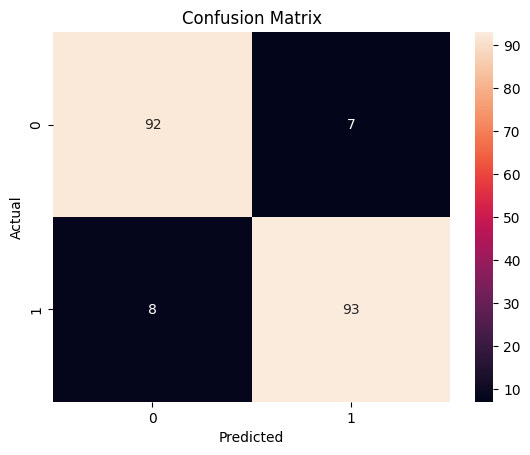

In [16]:
%matplotlib inline

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [9]:
print(classification_report(y_true, y_pred, target_names=CLASSES_LIST))


              precision    recall  f1-score   support

 NonViolence       0.92      0.93      0.92        99
    Violence       0.93      0.92      0.93       101

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.92       200
weighted avg       0.93      0.93      0.93       200



In [18]:
import time

In [19]:
def measure_latency(model, input_data, iterations=100):
    # Warm-up
    for _ in range(10):
        _ = model(input_data, training=False)
    
    start_time = time.time()
    for _ in range(iterations):
        _ = model(input_data, training=False)
    end_time = time.time()
    
    avg_latency = (end_time - start_time) / iterations
    print(f'Rata-rata latensi per inferensi: {avg_latency * 1000:.2f} ms')


In [21]:
measure_latency(model, tf.random.normal((1, SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))

Rata-rata latensi per inferensi: 6176.74 ms
